In [12]:
from scipy import interpolate
from calculate_MIH_general import tms,readAF,computeMIH

In [ ]:
#Each time series in an ascii txt file should contain two columns: time [sec] and surface elevation [m].
#examples:
tmsf="example_general/tms_00501.txt"
#tmsf="example_general/spletaD4_m.txt"
#tmsf="example_general/spletaD6_m.txt"
#tmsf="example_general/spletaD6_3x_m.txt"

In [ ]:
#inspect a plot for chosen time serie
import matplotlib.pyplot as plt
import numpy as np  
data=np.loadtxt(tmsf)
plt.figure(figsize=(20,4))
plt.plot(data[:,0],data[:,1])   
plt.xlabel('time [sec]')
plt.ylabel('surface elevation [m]')
plt.title('Time series')
plt.grid()
plt.show()

In [ ]:
#read amplification factors
af=readAF("../ampfactors/global_ampf_v04.txt")
#printing the first 10 lines of the ampfactor file, which contains the location of the POIs and the corresponding amplification factors
print("".join(open("../ampfactors/global_ampf_v04.txt").readlines()[:10]))

Prosessing mariogram from example_general/tms_00501.txt


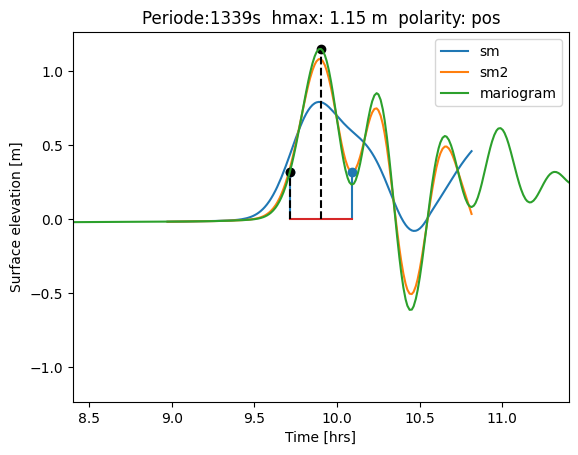


Inspect plot: plot/plot_tms_tms_00501_id03700_eta.png
MIH for mariogram example_general/tms_00501.txt is 3.8 m with offshore wave amplitude of 1.1 m, wave period 1339 s and amplification factor 3.27.


<Figure size 640x480 with 0 Axes>

In [11]:
# calculate MIH for the chosen time series
ampfact_id="id03700"
plot=True
plot_dir="plot"
plot_name="plot_tms_"+tmsf.split("/")[-1].split(".")[0]+"_"+ampfact_id
results=tms(tmsf, af, ampfact_id, plot, plot_dir, plot_name,tsample=5)   


### HySEA - calculating MIH from multiple time series using existing example 


Run postprocessing script to extract wave parameters for all the time series and save them in a txt file (wave periode, max wave height, amplification factor, MIH)
Ouput from HySEA (mariograms) are found in example_HySEA/result_ts.nc



In [ ]:
#import subprocess
#subprocess.run(["wsl","../postprocess_HySEA/postprocess_HySea", "example_HySEA/result_ts.nc"], check=True)

import os
os.system("../postprocess_HySEA/postprocess_HySea example_HySEA/result_ts.nc")

The command above will create a the file with wave characteristics needed for calculating MIH with amplification factors
First 10 lines shown below 

In [ ]:
print("".join(open("example_HySEA/result_ts.nc.offshore.txt").readlines()[:10]))

In [ ]:
#a id file that connects the location of the POIs in HySEA with the corresponding id in the ampfact file is also needed, first 10 lines shown below
print("".join(open("example_HySEA/result_ts.nc_id.txt").readlines()[:10]))

In [ ]:
from calculate_MIH_HySEA import computeMIH
tms_file="example_HySEA/result_ts.nc"                 #output from HySEA, location of POIs from ampfact
tms_id_file="example_HySEA/result_ts.nc_id.txt"       #input id file, location of POIs in HySEA with corresponding id
out_results="example_HySEA/calculated_MIH_HySEA.txt"  #name of outputfile
computeMIH(af,tms_file, tms_id_file, out_results)

In [ ]:
print("".join(open("example_HySEA/calculated_MIH_HySEA.txt").readlines()[:10]))